<a href="https://colab.research.google.com/github/sunshinesam72007-rgb/ML_ASSIGNMENT/blob/main/Sameeksha_ML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [9]:
df = pd.read_csv("agriculture_yield_dataset.csv")
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [10]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5      

In [11]:
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [12]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


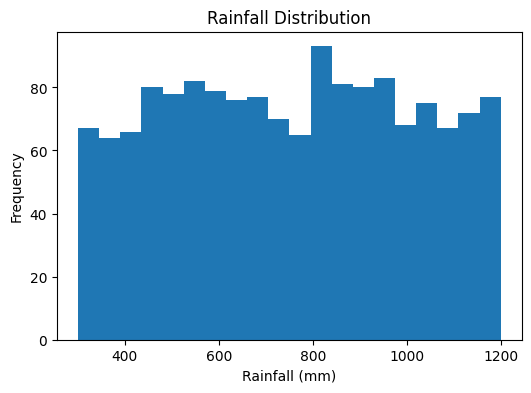

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

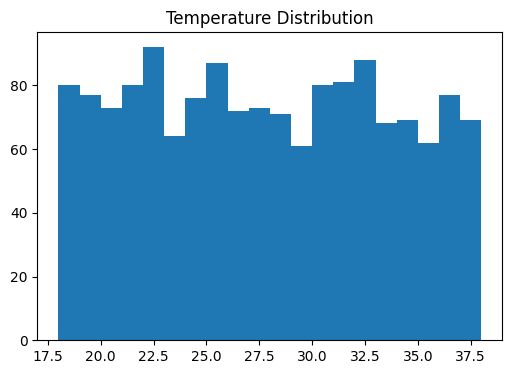

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins=20)
plt.title("Temperature Distribution")
plt.show()

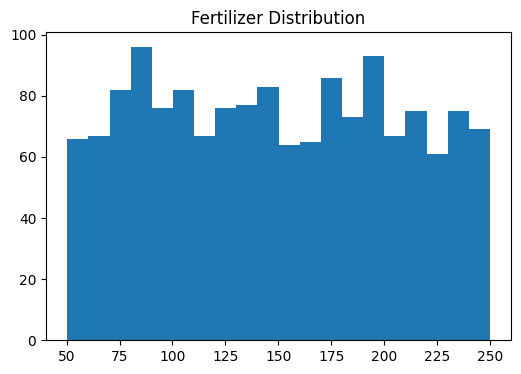

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins=20)
plt.title("Fertilizer Distribution")
plt.show()

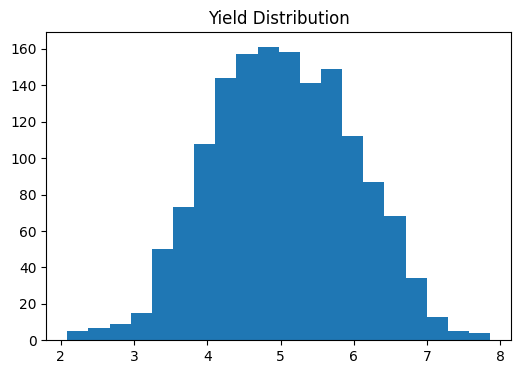

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


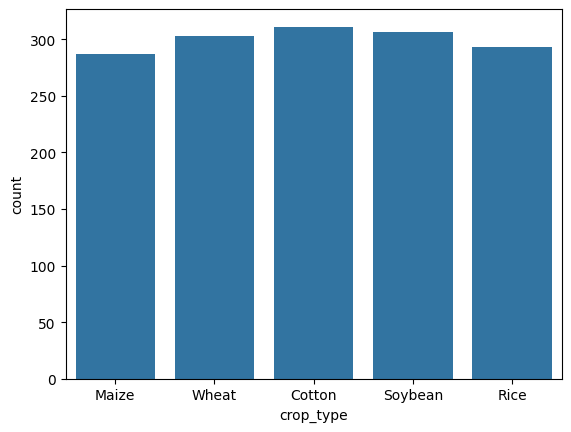

In [17]:
print(df['crop_type'].value_counts())

sns.countplot(x='crop_type', data=df)
plt.show()

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


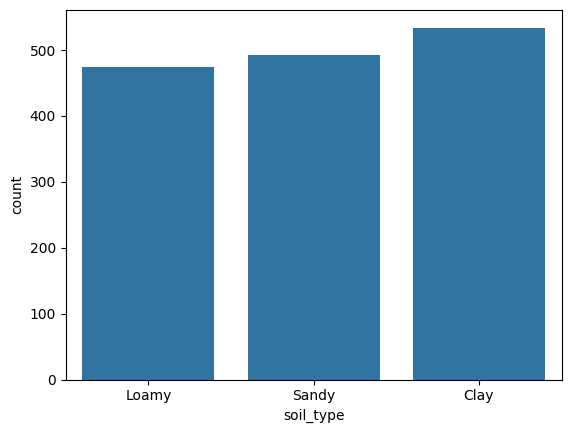

In [18]:
print(df['soil_type'].value_counts())

sns.countplot(x='soil_type', data=df)
plt.show()

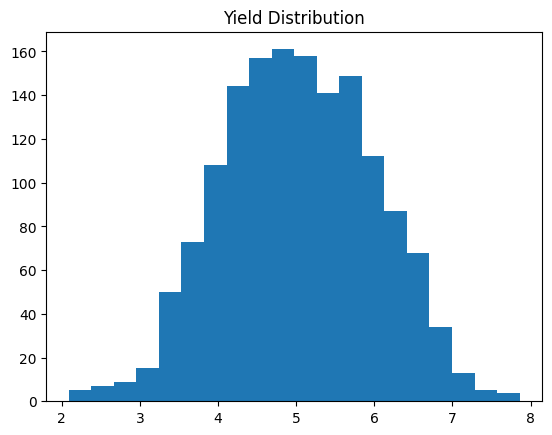

In [19]:
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.show()

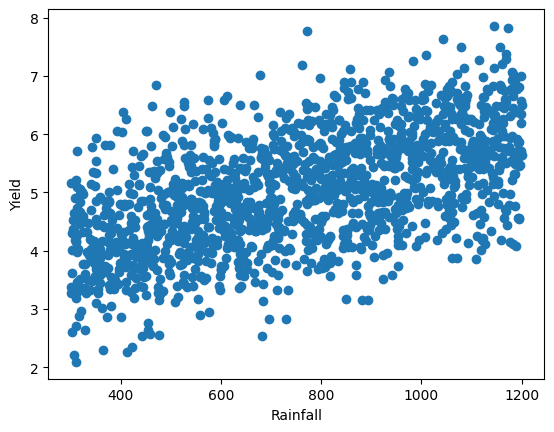

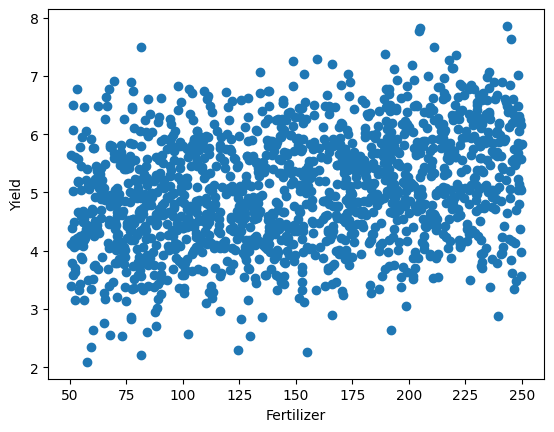

In [21]:
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

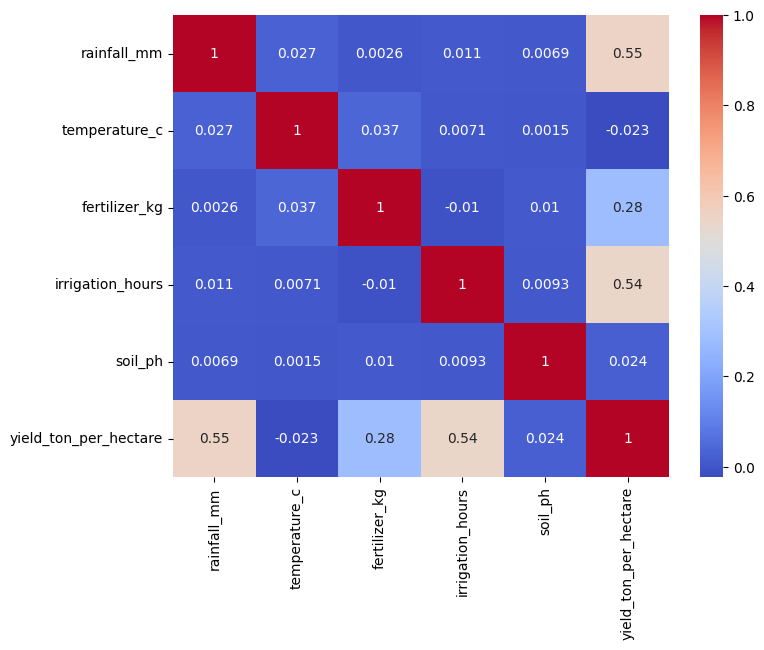

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [22]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

print(corr['yield_ton_per_hectare'].sort_values(ascending=False))

In [23]:
crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_avg)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [24]:
soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_avg)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [25]:
df_encoded = pd.get_dummies(df, columns=['crop_type','soil_type'])

print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_type_Clay  soil_type_Loamy  \


In [26]:
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print(X.head())
print(y.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Cotton  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0             False             True           False              False   
1             False             True           False              False   
2             False            False           False              False   
3             False             True           False              False   
4              True            False           False              False   

   crop_type_Wheat  soil_type_Clay  soil_type_Loamy  soil_type_Sandy  
0            False         

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200, 13)
(300, 13)
(1200,)
(300,)


In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coef_df.sort_values(by='Coefficient', ascending=False))

Intercept:
1.9111026182800726
              Feature  Coefficient
7      crop_type_Rice     0.477369
11    soil_type_Loamy     0.365627
3    irrigation_hours     0.198327
8   crop_type_Soybean     0.095096
10     soil_type_Clay     0.062653
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
9     crop_type_Wheat    -0.038149
6     crop_type_Maize    -0.147693
5    crop_type_Cotton    -0.386623
12    soil_type_Sandy    -0.428280
